# Comparing AdvDIFFormer and GREAD, trying to explain why they perform worse.

Results are aggregated over independent training seeds `42`, `43`, and `44` from the benchmark run.

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT if (ROOT / "configs" / "run.yaml").exists() else ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.embedding_analysis_utils import (
    compute_cross_graph_knn_purity,
    compute_edge_cosine_gap,
    compute_knn_purity,
    evaluate_kmeans_nmi,
)

ARTIFACT_ROOT = PROJECT_ROOT.parent / "embedding_diagnostics" / "full"
RESULT_ROOT = PROJECT_ROOT / "analysis" / "results"
FIGURE_ROOT = RESULT_ROOT / "embedding_figures"
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
MODELS = ["HiD-Net", "MTGCN", "AdvDIFFormer", "GREAD"]
HOMOPHILY_LEVELS = ["Low", "Medium", "High"]
TRAINING_SEEDS = [42, 43, 44]
MODEL_FILES = {"HiD-Net": "hid_net", "MTGCN": "mtgcn", "AdvDIFFormer": "advdifformer", "GREAD": "gread"}
HOMOPHILY_FILES = {"Low": "lo", "Medium": "mid", "High": "hi"}
COLORS = {"HiD-Net": "#1f77b4", "MTGCN": "#2ca02c", "AdvDIFFormer": "#ff7f0e", "GREAD": "#d62728"}
KMEANS_SEEDS = range(20)


The analyzed vectors are the original unprojected 64D backbone outputs before `MLPReadout`. All diagnostics use complete held-out graphs. 

In [ ]:
def artifact_path(model, homophily, seed):
    stem = f"{MODEL_FILES[model]}_{HOMOPHILY_FILES[homophily]}"
    seeded = ARTIFACT_ROOT / f"{stem}_s{seed}.npz"
    legacy = ARTIFACT_ROOT / f"{stem}.npz"
    return seeded if seeded.exists() else legacy if seed == 42 else seeded


artifact_paths = {(model, homophily, seed): artifact_path(model, homophily, seed) for model in MODELS for homophily in HOMOPHILY_LEVELS for seed in TRAINING_SEEDS}
ARTIFACTS_AVAILABLE = all(path.exists() for path in artifact_paths.values())
representations = {key: dict(np.load(path)) for key, path in artifact_paths.items()} if ARTIFACTS_AVAILABLE else {}
if ARTIFACTS_AVAILABLE:
    for homophily in HOMOPHILY_LEVELS:
        for seed in TRAINING_SEEDS:
            reference = representations[(MODELS[0], homophily, seed)]
            for model in MODELS[1:]:
                candidate = representations[(model, homophily, seed)]
                assert np.array_equal(reference["test_label"], candidate["test_label"])
                assert np.array_equal(reference["test_graph_id"], candidate["test_graph_id"])
                assert np.array_equal(reference["test_edge_index"], candidate["test_edge_index"])
    print("Matched artifacts loaded: 36 checkpoints, 5,972 test nodes each, 64D embeddings.")
else:
    print("Checkpoint arrays are absent; using committed result caches.")


Matched artifacts loaded: 36 checkpoints, 5,972 test nodes each, 64D embeddings.


In [ ]:
benchmark_path = RESULT_ROOT / "benchmark_results.csv"
if ARTIFACTS_AVAILABLE:
    benchmark_rows = []
    for (model, homophily, training_seed), data in representations.items():
        checkpoint = Path(str(data["checkpoint"]))
        summaries = list(checkpoint.parent.parent.glob("wandb/run-*/files/wandb-summary.json"))
        if len(summaries) != 1:
            raise RuntimeError(f"Expected one W&B summary beside {checkpoint}.")
        summary = json.loads(summaries[0].read_text(encoding="utf-8"))
        benchmark_rows.append({"model": model, "homophily": homophily, "training_seed": training_seed, "benchmark_accuracy": summary["test_best_rerun/accuracy"]})
    benchmark_results = pd.DataFrame(benchmark_rows)
    benchmark_results.to_csv(benchmark_path, index=False)
else:
    benchmark_results = pd.read_csv(benchmark_path)

benchmark_summary = benchmark_results.groupby(["model", "homophily"], observed=True)["benchmark_accuracy"].agg(["mean", "std"]).reset_index().rename(columns={"mean": "benchmark_accuracy", "std": "benchmark_accuracy_std"})
display(benchmark_summary.pivot(index="model", columns="homophily", values="benchmark_accuracy").reindex(index=MODELS, columns=HOMOPHILY_LEVELS).round(3))


homophily,Low,Medium,High
model,,,
HiD-Net,0.328,0.452,0.732
MTGCN,0.335,0.442,0.736
AdvDIFFormer,0.335,0.371,0.604
GREAD,0.336,0.379,0.528


## Diagnostics

In [ ]:
core_path = RESULT_ROOT / "core_embedding_metrics.csv"
kmeans_path = RESULT_ROOT / "kmeans_nmi_seeds.csv"
if ARTIFACTS_AVAILABLE:
    core_rows, kmeans_frames = [], []
    for model in MODELS:
        for homophily in HOMOPHILY_LEVELS:
            for training_seed in TRAINING_SEEDS:
                data = representations[(model, homophily, training_seed)]
                test_x, test_y = data["test_embedding"], data["test_label"]
                clustering = evaluate_kmeans_nmi(test_x, test_y, KMEANS_SEEDS)
                clustering.insert(0, "training_seed", training_seed)
                clustering.insert(0, "homophily", homophily)
                clustering.insert(0, "model", model)
                kmeans_frames.append(clustering)
                local_purity = compute_knn_purity(test_x, test_y)
                cross_graph = compute_cross_graph_knn_purity(test_x, test_y, data["test_graph_id"])
                edge_cosine = compute_edge_cosine_gap(test_x, data["test_edge_index"], test_y)
                core_rows.append({"model": model, "homophily": homophily, "training_seed": training_seed, "knn10_purity": local_purity, **cross_graph, **edge_cosine})
    core_results = pd.DataFrame(core_rows)
    kmeans_results = pd.concat(kmeans_frames, ignore_index=True)
    core_results.to_csv(core_path, index=False)
    kmeans_results.to_csv(kmeans_path, index=False)
else:
    core_results = pd.read_csv(core_path)
    kmeans_results = pd.read_csv(kmeans_path)

kmeans_checkpoint = kmeans_results.groupby(["model", "homophily", "training_seed"], observed=True)["nmi"].mean().reset_index().rename(columns={"nmi": "kmeans_nmi"})
seed_results = core_results.merge(kmeans_checkpoint, on=["model", "homophily", "training_seed"]).merge(benchmark_results, on=["model", "homophily", "training_seed"])
metric_columns = [column for column in seed_results.columns if column not in {"model", "homophily", "training_seed"}]
means = seed_results.groupby(["model", "homophily"], observed=True)[metric_columns].mean().reset_index()
stds = seed_results.groupby(["model", "homophily"], observed=True)[metric_columns].std().add_suffix("_std").reset_index()
all_results = means.merge(stds, on=["model", "homophily"])


In [ ]:
summary_metrics = ["benchmark_accuracy", "kmeans_nmi", "knn10_purity", "cross_graph_purity", "same_graph_fraction", "same_edge_cosine", "different_edge_cosine", "edge_cosine_gap"]
summary_columns = ["model"] + [column for metric in summary_metrics for column in (metric, f"{metric}_std")]
high_summary = all_results[all_results["homophily"] == "High"][summary_columns].set_index("model").reindex(MODELS).reset_index()
high_summary.to_csv(RESULT_ROOT / "embedding_summary.csv", index=False)
display(high_summary.round(3))


,model,benchmark_accuracy,benchmark_accuracy_std,kmeans_nmi,kmeans_nmi_std,knn10_purity,knn10_purity_std,cross_graph_purity,cross_graph_purity_std,same_graph_fraction,same_graph_fraction_std,same_edge_cosine,same_edge_cosine_std,different_edge_cosine,different_edge_cosine_std,edge_cosine_gap,edge_cosine_gap_std
0,HiD-Net,0.732,0.001,0.503,0.008,0.622,0.008,0.528,0.006,0.331,0.009,0.643,0.007,0.445,0.007,0.198,0.002
1,MTGCN,0.736,0.002,0.424,0.023,0.536,0.019,0.469,0.014,0.215,0.020,0.543,0.012,0.366,0.012,0.178,0.001
2,AdvDIFFormer,0.604,0.004,0.362,0.007,0.529,0.005,0.388,0.002,0.401,0.009,0.507,0.007,0.238,0.012,0.269,0.006
3,GREAD,0.528,0.006,0.328,0.001,0.401,0.009,0.323,0.004,0.237,0.014,0.846,0.001,0.805,0.002,0.041,0.001


## Figures

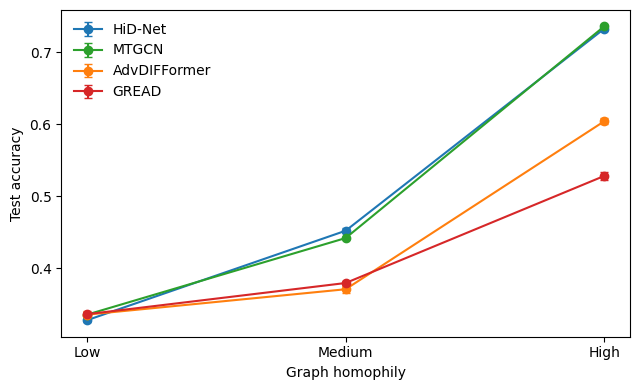

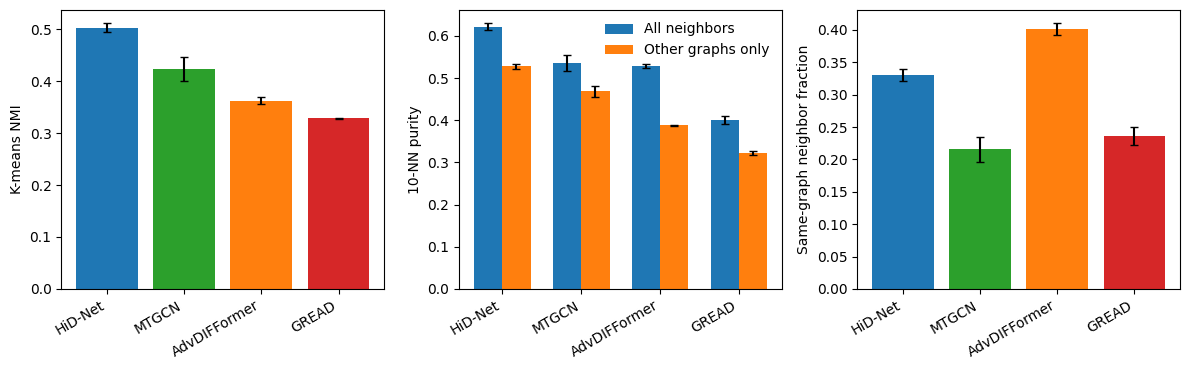

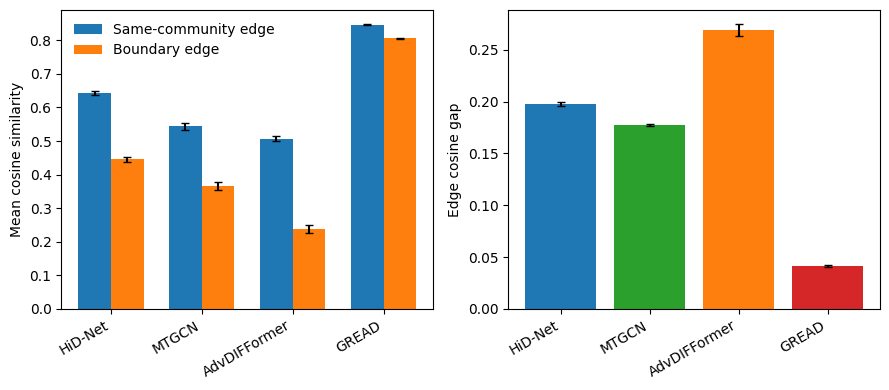

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for model in MODELS:
    subset = benchmark_summary[benchmark_summary["model"] == model].set_index("homophily").reindex(HOMOPHILY_LEVELS)
    ax.errorbar(HOMOPHILY_LEVELS, subset["benchmark_accuracy"], yerr=subset["benchmark_accuracy_std"], marker="o", capsize=3, color=COLORS[model], label=model)
ax.set(xlabel="Graph homophily", ylabel="Test accuracy")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "01_benchmark_accuracy.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
x = np.arange(len(MODELS))
axes[0].bar(x, high_summary["kmeans_nmi"], yerr=high_summary["kmeans_nmi_std"], capsize=3, color=[COLORS[model] for model in MODELS])
axes[0].set_ylabel("K-means NMI")
axes[1].bar(x - 0.18, high_summary["knn10_purity"], 0.36, yerr=high_summary["knn10_purity_std"], capsize=3, label="All neighbors")
axes[1].bar(x + 0.18, high_summary["cross_graph_purity"], 0.36, yerr=high_summary["cross_graph_purity_std"], capsize=3, label="Other graphs only")
axes[1].set_ylabel("10-NN purity")
axes[1].legend(frameon=False)
axes[2].bar(x, high_summary["same_graph_fraction"], yerr=high_summary["same_graph_fraction_std"], capsize=3, color=[COLORS[model] for model in MODELS])
axes[2].set_ylabel("Same-graph neighbor fraction")
for ax in axes:
    ax.set_xticks(x, MODELS, rotation=30, ha="right")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "02_high_homophily_recoverability.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(x - 0.18, high_summary["same_edge_cosine"], 0.36, yerr=high_summary["same_edge_cosine_std"], capsize=3, label="Same-community edge")
axes[0].bar(x + 0.18, high_summary["different_edge_cosine"], 0.36, yerr=high_summary["different_edge_cosine_std"], capsize=3, label="Boundary edge")
axes[0].set_ylabel("Mean cosine similarity")
axes[0].legend(frameon=False)
axes[1].bar(x, high_summary["edge_cosine_gap"], yerr=high_summary["edge_cosine_gap_std"], capsize=3, color=[COLORS[model] for model in MODELS])
axes[1].set_ylabel("Edge cosine gap")
for ax in axes:
    ax.set_xticks(x, MODELS, rotation=30, ha="right")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "03_edge_boundary_contrast.png", dpi=160)
plt.show()
